In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


In [2]:
df = pd.read_csv("/kaggle/input/datasets/hridoybanik/practice-4-dataset/heart.csv")


In [3]:
df.head(5)

,Age,Sex,ChestPainType,RestingBP,Cholesterol,FastingBS,RestingECG,MaxHR,ExerciseAngina,Oldpeak,ST_Slope,HeartDisease
0,40,M,ATA,140,289,0,Normal,172,N,0.0,Up,0
1,49,F,NAP,160,180,0,Normal,156,N,1.0,Flat,1
2,37,M,ATA,130,283,0,ST,98,N,0.0,Up,0
3,48,F,ASY,138,214,0,Normal,108,Y,1.5,Flat,1
4,54,M,NAP,150,195,0,Normal,122,N,0.0,Up,0


<Axes: xlabel='FastingBS', ylabel='Count'>

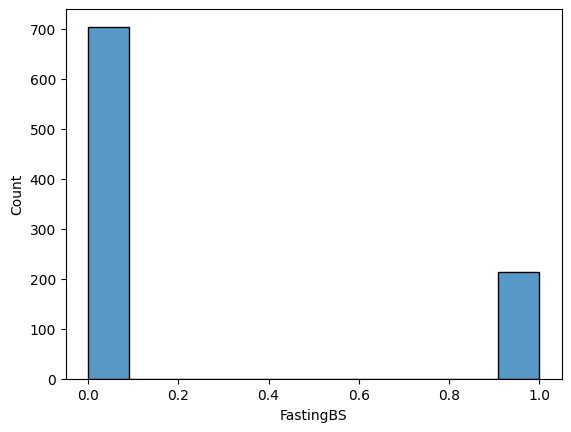

In [18]:
sns.histplot(df, x = 'FastingBS')

In [14]:
X = df.drop("HeartDisease", axis = 1)
y = df['HeartDisease']

In [15]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=42)


In [30]:
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.svm import SVC
from sklearn import svm

In [19]:
numeric_cols = ["Age","RestingBP","Cholesterol","FastingBS","MaxHR","Oldpeak"]
categoric_cols = ['Sex','ChestPainType','RestingECG','ExerciseAngina','ST_Slope']

In [24]:
p1 = Pipeline(
    steps = [
        ('Scaling_numerical data', StandardScaler())
        
    ]
)
p2 = Pipeline(
    steps = [
        ('OHE', OneHotEncoder(drop='first',sparse_output=False))
        
    ]
)

In [25]:
preprocessing = ColumnTransformer(
    transformers = [
        ("Preprocessor_num", p1, numeric_cols),
        ("Preprocessor_cat", p2, categoric_cols)
    ], remainder = 'passthrough'
)

In [31]:
model_training = Pipeline(
    steps = [
        ("process", preprocessing),
        ("model_training", svm.SVC(kernel='linear'))  
    ]
)

In [32]:
model_training.fit(X_train, y_train)

Pipeline(steps=[('process',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('Preprocessor_num',
                                                  Pipeline(steps=[('Scaling_numerical '
                                                                   'data',
                                                                   StandardScaler())]),
                                                  ['Age', 'RestingBP',
                                                   'Cholesterol', 'FastingBS',
                                                   'MaxHR', 'Oldpeak']),
                                                 ('Preprocessor_cat',
                                                  Pipeline(steps=[('OHE',
                                                                   OneHotEncoder(drop='first',
                                                                                 sparse_output=False))]),
                                                  ['Sex', 'ChestPainType',
                                                   'RestingECG',
                                                   'ExerciseAngina',
                                                   'ST_Slope'])])),
                ('model_training', SVC(kernel='linear'))])

In [35]:
y_pred = model_training.predict(X_test)

In [36]:
from sklearn.metrics import accuracy_score, precision_score, f1_score
print("For linear Kernel")
print("Testing Accuracy")
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")


For linear Kernel
Testing Accuracy
Accuracy:  0.8533
Precision: 0.9000
F1 Score:  0.8696


In [38]:
model_training_2 = Pipeline(
    steps = [
        ("process", preprocessing),
        ("model_training", svm.SVC(kernel='poly'))  
    ]
)
model_training_2.fit(X_train,y_train)
y_pred = model_training_2.predict(X_test)
print("For Polynomial Kernel")
print("Testing Accuracy")
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")



For Polynomial Kernel
Testing Accuracy
Accuracy:  0.8533
Precision: 0.9000
F1 Score:  0.8696


In [41]:
model_training_3 = Pipeline(
    steps = [
        ("process", preprocessing),
        ("model_training", svm.SVC(kernel='rbf'))  
    ]
)
model_training_3.fit(X_train,y_train)
y_pred = model_training_3.predict(X_test)
print("For RBF Kernel")
print("Testing Accuracy")
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")

For RBF Kernel
Testing Accuracy
Accuracy:  0.8587
Precision: 0.8857
F1 Score:  0.8774


In [42]:
model_training_4 = Pipeline(
    steps = [
        ("process", preprocessing),
        ("model_training", svm.SVC(kernel='sigmoid'))  
    ]
)
model_training_4.fit(X_train,y_train)
y_pred = model_training_4.predict(X_test)
print("For Sigmoid Kernel")
print("Testing Accuracy")
# Calculate metrics
accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"F1 Score:  {f1:.4f}")

For Sigmoid Kernel
Testing Accuracy
Accuracy:  0.7772
Precision: 0.8113
F1 Score:  0.8075
